In [ ]:
pip install yfinance pandas numpy matplotlib seaborn


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
tickers = ["AAPL", "MSFT", "TSLA", "INFY"]
start_date = "2023-01-01"
end_date = "2024-01-01"

data = yf.download(tickers, start=start_date, end=end_date, group_by="ticker")


/tmp/ipython-input-1987833865.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date, group_by="ticker")
[*********************100%***********************]  4 of 4 completed


In [ ]:
stock_df = []

for ticker in tickers:
    df = data[ticker].copy()
    df["Ticker"] = ticker
    df.reset_index(inplace=True) # Re-added this line to make 'Date' a column
    stock_df.append(df)

# Concatenate and reset index once, ignoring the original indices
stock_df = pd.concat(stock_df, ignore_index=True)
stock_df.tail()

Price,Date,Open,High,Low,Close,Volume,Ticker
995,2023-12-22,17.603999,17.782862,17.547515,17.660482,7018100,INFY
996,2023-12-26,17.547513,17.575756,17.293339,17.368650,3866200,INFY
997,2023-12-27,17.547516,17.585172,17.368653,17.509861,4338000,INFY
998,2023-12-28,17.519277,17.585174,17.443966,17.472206,3308700,INFY
999,2023-12-29,17.415721,17.443963,17.246271,17.302753,2864800,INFY


In [ ]:
stock_df["Daily Return"] = stock_df.groupby("Ticker")["Close"].pct_change()

In [ ]:
stock_df["Cumulative Return"] = (
    1 + stock_df["Daily Return"]
).groupby(stock_df["Ticker"]).cumprod() - 1


In [ ]:
avg_return = stock_df.groupby("Ticker")["Daily Return"].mean() * 100
print(avg_return)


Ticker
AAPL    0.183493
INFY    0.026209
MSFT    0.197166
TSLA    0.389272
Name: Daily Return, dtype: float64


In [ ]:
volatility = stock_df.groupby("Ticker")["Daily Return"].std() * 100
print(volatility)


Ticker
AAPL    1.257002
INFY    1.558261
MSFT    1.582433
TSLA    3.316561
Name: Daily Return, dtype: float64


In [ ]:
def max_drawdown(series):
    cumulative = (1 + series).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    return drawdown.min()

max_dd = stock_df.groupby("Ticker")["Daily Return"].apply(max_drawdown)
print(max_dd)


Ticker
AAPL   -0.149323
INFY   -0.241927
MSFT   -0.129876
TSLA   -0.327197
Name: Daily Return, dtype: float64


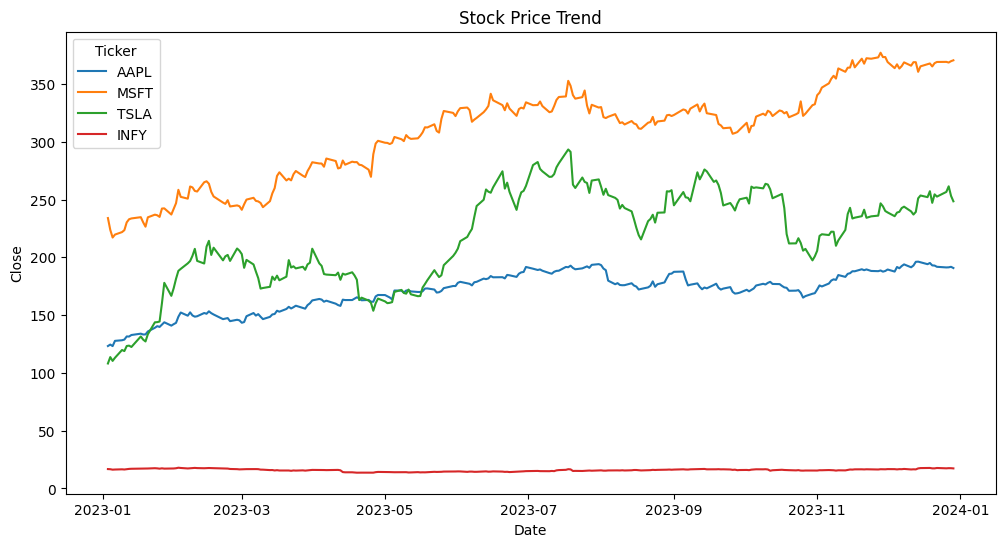

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(data=stock_df, x="Date", y="Close", hue="Ticker")
plt.title("Stock Price Trend")
plt.show()

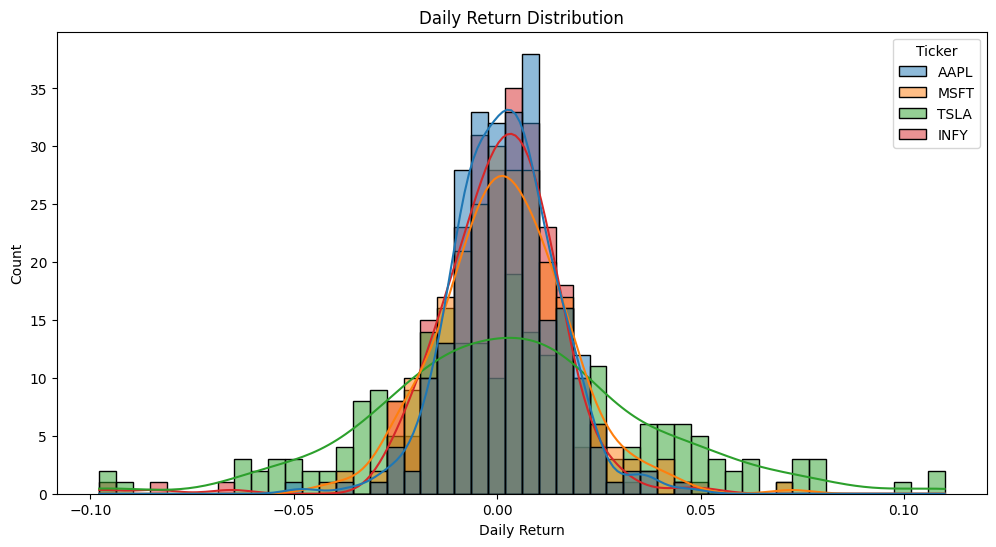

In [ ]:
plt.figure(figsize=(12,6))

# Ensure 'Daily Return' column exists for plotting
if 'Daily Return' not in stock_df.columns:
    stock_df["Daily Return"] = stock_df.groupby("Ticker")["Close"].pct_change()

sns.histplot(
    data=stock_df,
    x="Daily Return",
    hue="Ticker",
    bins=50,
    kde=True
)
plt.title("Daily Return Distribution")
plt.show()

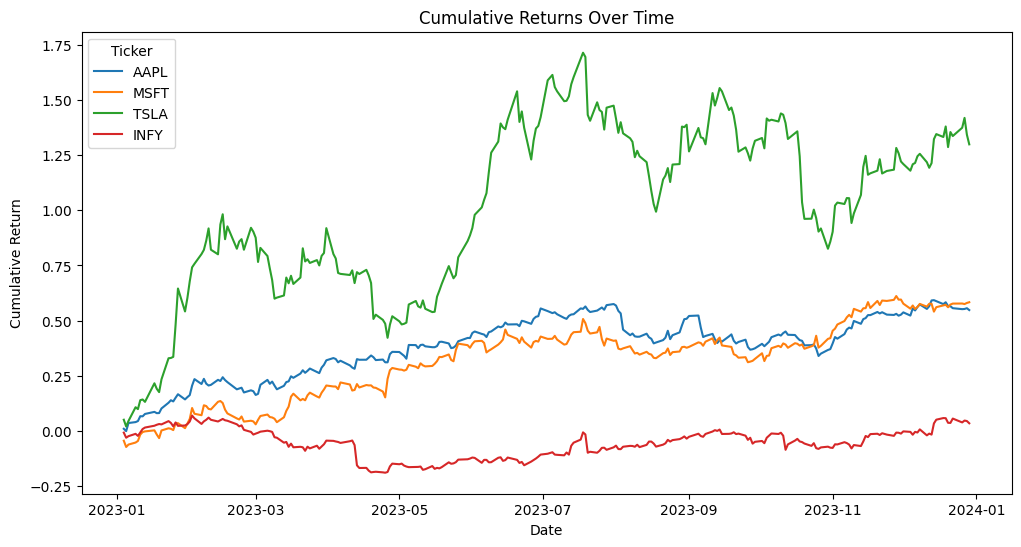

In [ ]:
plt.figure(figsize=(12,6))

# Ensure 'Cumulative Return' column exists for plotting
if 'Cumulative Return' not in stock_df.columns:
    stock_df["Cumulative Return"] = (
        1 + stock_df["Daily Return"]
    ).groupby(stock_df["Ticker"]).cumprod() - 1

sns.lineplot(
    data=stock_df,
    x="Date",
    y="Cumulative Return",
    hue="Ticker"
)
plt.title("Cumulative Returns Over Time")
plt.show()

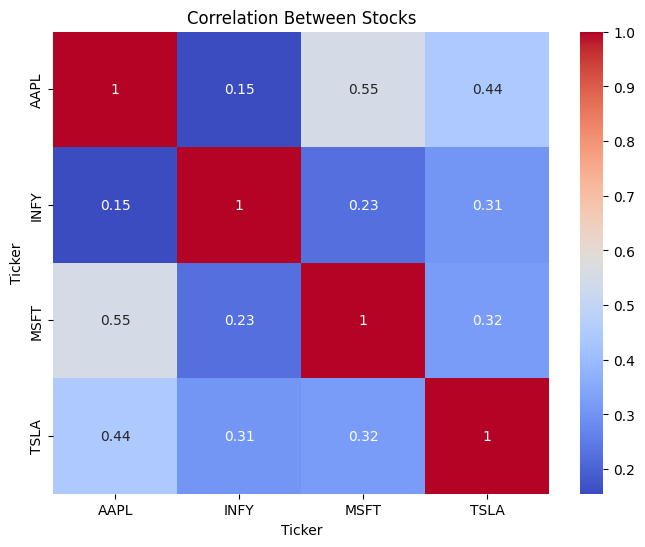

In [ ]:
pivot_returns = stock_df.pivot(
    index="Date",
    columns="Ticker",
    values="Daily Return"
)

plt.figure(figsize=(8,6))
sns.heatmap(
    pivot_returns.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Between Stocks")
plt.show()


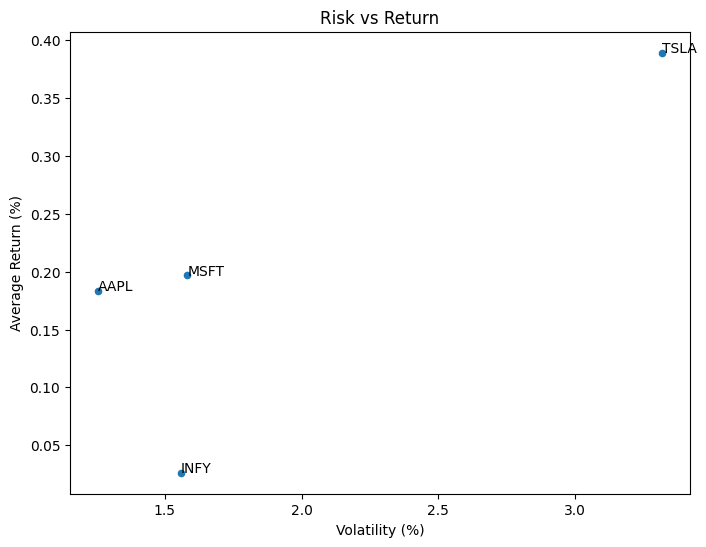

In [ ]:
risk_return = pd.DataFrame({
    "Average Return (%)": avg_return,
    "Volatility (%)": volatility
})

risk_return.plot(kind="scatter", x="Volatility (%)", y="Average Return (%)", figsize=(8,6))
for ticker in risk_return.index:
    plt.annotate(ticker,
                 (risk_return.loc[ticker, "Volatility (%)"],
                  risk_return.loc[ticker, "Average Return (%)"]))

plt.title("Risk vs Return")
plt.show()


In [ ]:
stock_df.to_csv("final_stock_analysis.csv", index=False)
print("Final analyzed dataset saved!")


NameError: name 'stock_df' is not defined